# Linear Regression

### 1. Import necessary libraries

Import all the necessary libraries to train the Linear Regression model.

In [1]:
#import libraries
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

from pathlib import Path


### 2. Define Paths

Declare the path to call the saved tf-idf features. Additionally, define the path to store the results of the training.

In [2]:
#define paths
FEATURE_DIR = "C:/Users/HP/ecom-reviews-sentiment-analysis/knowledge_representation"
GRAPH_DIR = "C:/Users/HP/ecom-reviews-sentiment-analysis/model_training/results"

#load tf-idf features
with open(f"{FEATURE_DIR}/tfidf_features.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(f"{FEATURE_DIR}/tfidf_X_val.pkl", "rb") as f:
    X_val = pickle.load(f)

with open(f"{FEATURE_DIR}/tfidf_X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

#load labels
with open(f"{FEATURE_DIR}/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(f"{FEATURE_DIR}/y_val.pkl", "rb") as f:
    y_val = pickle.load(f)

with open(f"{FEATURE_DIR}/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)


LABEL_NAMES = ["negative", "neutral", "positive"]

OUTPUT_DIR = Path(GRAPH_DIR) / "logistic_regression"
OUTPUT_DIR.mkdir(exist_ok=True)

Make sure all the loads are correct

In [3]:
#verify all loads are correct
print("Training set")
print("X_train:", X_train.shape)
print("y_train:", len(y_train))

print("\nValidation set")
print("X_val:", X_val.shape)
print("y_val:", len(y_val))

print("\nTest set")
print("X_test:", X_test.shape)
print("y_test:", len(y_test))

Training set
X_train: (428, 1106)
y_train: 428

Validation set
X_val: (92, 1106)
y_val: 92

Test set
X_test: (92, 1106)
y_test: 92


### 3. Class Distribution

Print the count of positive, negative, and neutral reviews for all three sets (train, test, validation)

In [4]:
#check class distribution
print("Training labels:")
print(pd.Series(y_train).value_counts())

print("\nValidation labels:")
print(pd.Series(y_val).value_counts())

print("\nTest labels:")
print(pd.Series(y_test).value_counts())

Training labels:
sentiment
positive    220
negative    134
neutral      74
Name: count, dtype: int64

Validation labels:
sentiment
positive    48
negative    29
neutral     15
Name: count, dtype: int64

Test labels:
sentiment
positive    47
negative    29
neutral     16
Name: count, dtype: int64


### 4. Evaluation Metrics

Define the function for calling the evaluation metrcis function.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    """
    Evaluate a trained classifier and return metrics.
    """

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0
    )

    accuracy = accuracy_score(y_test, y_pred)

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=LABEL_NAMES,
            zero_division=0
        )
    )

    metrics = {
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Negative F1": round(report["negative"]["f1-score"], 4),
        "Neutral F1": round(report["neutral"]["f1-score"], 4),
        "Positive F1": round(report["positive"]["f1-score"], 4),
        "Macro Precision": round(report["macro avg"]["precision"], 4),
        "Macro Recall": round(report["macro avg"]["recall"], 4),
    }

    return metrics, y_pred

### 5. Confusion Matrix

Define the function for confusion matrix. 

In [6]:
def plot_confusion_matrix(name, y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.title(f"Confusion Matrix - {name}")

    plt.tight_layout()

    save_path = OUTPUT_DIR / f"cm_{name.lower().replace(' ', '_')}.png"

    plt.savefig(save_path, dpi=300)
    plt.show()

    print(f"Saved confusion matrix to:\n{save_path}")

### 6. Hyperparameter Adjustment

Define different C values. Print the accuracy and macro F1 results for each hyperparameter. Then, find the settings with the best validation Macro F1 score. 

In [7]:
C_values = [0.01, 0.1, 1, 10]

tuning_results = []

best_C = None
best_macro_f1 = -1

print("=" * 60)
print("LOGISTIC REGRESSION HYPERPARAMETER TUNING")
print("=" * 60)

for C in C_values:

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    accuracy = accuracy_score(y_val, y_val_pred)

    tuning_results.append({
        "C": C,
        "Accuracy": round(accuracy, 4),
        "Macro F1": round(macro_f1, 4)
    })

    print(
        f"C = {C:<5} | "
        f"Accuracy = {accuracy:.4f} | "
        f"Macro F1 = {macro_f1:.4f}"
    )

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_C = C

print("\nBest C:", best_C)
print("Best Validation Macro F1:", round(best_macro_f1, 4))

LOGISTIC REGRESSION HYPERPARAMETER TUNING
C = 0.01  | Accuracy = 0.5217 | Macro F1 = 0.2286
C = 0.1   | Accuracy = 0.5326 | Macro F1 = 0.2524
C = 1     | Accuracy = 0.7174 | Macro F1 = 0.5417
C = 10    | Accuracy = 0.7391 | Macro F1 = 0.6178

Best C: 10
Best Validation Macro F1: 0.6178


### 7. Validation Results

Print the tuned model accuracy and macro F1 results. Save them in a CSV file.

In [8]:
tuning_df = pd.DataFrame(tuning_results)

print("\nValidation Results")
print(tuning_df.sort_values("Macro F1", ascending=False))

tuning_df.to_csv(
    OUTPUT_DIR / "logistic_regression_tuning_results.csv",
    index=False
)


Validation Results
       C  Accuracy  Macro F1
3  10.00    0.7391    0.6178
2   1.00    0.7174    0.5417
1   0.10    0.5326    0.2524
0   0.01    0.5217    0.2286


### 8. Train Final Model

Train the final model using the best C value. 

In [9]:
lr_model = LogisticRegression(
    C=best_C,
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

print(f"\nFinal model trained with C = {best_C}")


Final model trained with C = 10


### 9. Evaluate the model on the test set

Test the model on the test dataset. Record the classification report for the test set.


Logistic Regression (alpha=10)
              precision    recall  f1-score   support

    negative       0.66      0.66      0.66        29
     neutral       0.25      0.06      0.10        16
    positive       0.76      0.96      0.85        47

    accuracy                           0.71        92
   macro avg       0.56      0.56      0.53        92
weighted avg       0.64      0.71      0.66        92



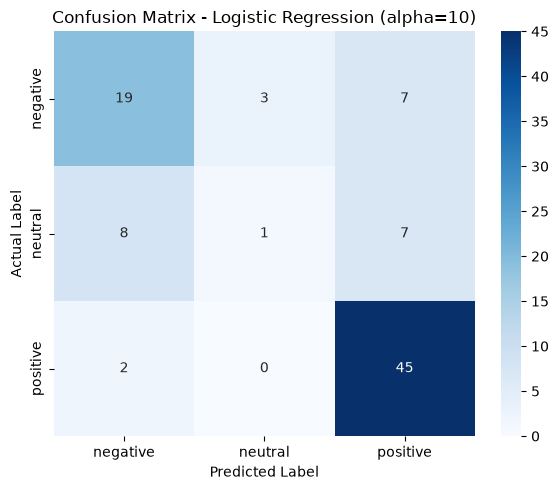

Saved confusion matrix to:
C:\Users\HP\ecom-reviews-sentiment-analysis\model_training\results\logistic_regression\cm_logistic_regression_(alpha=10).png


In [10]:
#Final test evaluation

test_metrics, y_test_pred = evaluate_model(
    f"Logistic Regression (alpha={best_C})",
    lr_model,
    X_test,
    y_test
)

plot_confusion_matrix(
    f"Logistic Regression (alpha={best_C})",
    y_test,
    y_test_pred
)

### 10. Save the Result

Save the final results in a CSV file.

In [11]:
#Save final results

results_df = pd.DataFrame([test_metrics])

print("\nFinal Test Results")
print(results_df)

results_df.to_csv(
    OUTPUT_DIR / "logistic_regression_final_results.csv",
    index=False
)

print(
    f"\nResults saved to:\n"
    f"{OUTPUT_DIR / 'logistic_regression_final_results.csv'}"
)


Final Test Results
                            Model  Accuracy  Macro F1  Weighted F1  \
0  Logistic Regression (alpha=10)    0.7065    0.5347       0.6577   

   Negative F1  Neutral F1  Positive F1  Macro Precision  Macro Recall  
0       0.6552         0.1       0.8491            0.556        0.5584  

Results saved to:
C:\Users\HP\ecom-reviews-sentiment-analysis\model_training\results\logistic_regression\logistic_regression_final_results.csv


### 11. Save the Model

Save the final trained Logistic Regression model.

In [13]:
with open(OUTPUT_DIR / "lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

print("Logistic Regression model saved!")

Logistic Regression model saved!
